# LoRA SFT Dataset Exploration

Explore the built LoRA SFT pair dataset for:

- class balance by split, hook, source system, and executor family
- cross-execution balance across systems, sessions, runs, levels, and tasks
- hook and trigger type coverage
- token-length distributions for LoRA sequence-length decisions
- corpus hygiene checks before split-freeze sign-off

Default input: `outputs/deepplanning/lora_sft/`. The notebook reads split JSONL files and keeps only metadata columns, so prompts and full targets are not held in memory.

In [10]:
%matplotlib inline
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    from tqdm.auto import tqdm
except ImportError:  # pragma: no cover - notebook fallback
    def tqdm(iterable, **_kwargs):
        return iterable

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start: Path | None = None) -> Path:
    env_root = os.environ.get("DEEPPLANNING_REPO_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()

    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pixi.toml").exists() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Could not find repo root; set DEEPPLANNING_REPO_ROOT")


REPO_ROOT = find_repo_root()
DATASET_DIR = Path(os.environ.get("LORA_SFT_DATASET_DIR", REPO_ROOT / "outputs" / "deepplanning" / "lora_sft")).expanduser().resolve()

SPLITS = ["train", "val", "held_out"]
EXPECTED_LEVELS = {1, 2, 3}
MAJORITY_CLASS_THRESHOLD = 0.70

EXECUTOR_FAMILY = {
    "C2": "qwen",
    "C2-nt": "qwen",
    "C2-noretry": "qwen",
    "C2-deepseek": "deepseek",
    "C2-deepseek-nt": "deepseek",
}

# Repo configs define C2-noretry as thinking-on; it only disables retries.
EXPECTED_REASONING_STRIPPED = {
    "C2": True,
    "C2-noretry": True,
    "C2-deepseek": True,
    "C2-nt": False,
    "C2-deepseek-nt": False,
}

print(f"Repo root: {REPO_ROOT}")
print(f"Dataset dir: {DATASET_DIR}")

Repo root: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight
Dataset dir: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/lora_sft


## Load Metadata

The JSONL rows contain large `input_messages`, `target_text`, and local raw text fields. For balance and coverage analysis, only top-level metadata is loaded.

In [11]:
KEEP_FIELDS = [
    "pair_id",
    "source_system",
    "session_id",
    "run_id",
    "trace_id",
    "source_observation_id",
    "task_id",
    "task_key",
    "level",
    "split",
    "phase",
    "step_index",
    "tool_index",
    "hook",
    "trigger_type",
    "overseer_mode",
    "decision_label",
    "parse_clean",
    "match_resolution",
    "input_messages_source",
    "target_text_source",
    "reasoning_stripped",
    "input_tokens",
    "output_tokens",
    "langfuse_model",
]


def load_jsonl_metadata(path: Path, file_split: str) -> pd.DataFrame:
    rows = []
    if not path.exists():
        raise FileNotFoundError(path)

    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(tqdm(handle, desc=f"reading {path.name}"), start=1):
            record = json.loads(line)
            row = {field: record.get(field) for field in KEEP_FIELDS}
            row["file_split"] = file_split
            row["line_no"] = line_no

            usage = record.get("usage")
            if isinstance(usage, dict):
                row["usage_total_tokens"] = usage.get("total")
                row["usage_input_cached_tokens"] = usage.get("input_cached_tokens")
                row["usage_output_reasoning_tokens"] = usage.get("output_reasoning_tokens")
            else:
                row["usage_total_tokens"] = None
                row["usage_input_cached_tokens"] = None
                row["usage_output_reasoning_tokens"] = None

            rows.append(row)

    return pd.DataFrame(rows)


def load_dataset(dataset_dir: Path) -> pd.DataFrame:
    split_paths = {split: dataset_dir / f"{split}.jsonl" for split in SPLITS}
    if all(path.exists() for path in split_paths.values()):
        frames = [load_jsonl_metadata(path, split) for split, path in split_paths.items()]
        return pd.concat(frames, ignore_index=True)

    all_pairs = dataset_dir / "all_pairs.jsonl"
    if all_pairs.exists():
        return load_jsonl_metadata(all_pairs, "all_pairs")

    raise FileNotFoundError(f"No split JSONL files or all_pairs.jsonl under {dataset_dir}")


pairs = load_dataset(DATASET_DIR)

pairs["level"] = pd.to_numeric(pairs["level"], errors="coerce").astype("Int64")
pairs["run_id"] = pd.to_numeric(pairs["run_id"], errors="coerce").astype("Int64")
pairs["step_index"] = pd.to_numeric(pairs["step_index"], errors="coerce").astype("Int64")
pairs["tool_index"] = pd.to_numeric(pairs["tool_index"], errors="coerce").astype("Int64")
pairs["parse_clean"] = pairs["parse_clean"].astype("boolean")
pairs["reasoning_stripped"] = pairs["reasoning_stripped"].astype("boolean")
for token_col in ["input_tokens", "output_tokens", "usage_total_tokens", "usage_input_cached_tokens", "usage_output_reasoning_tokens"]:
    pairs[token_col] = pd.to_numeric(pairs[token_col], errors="coerce")

pairs["executor_family"] = pairs["source_system"].map(EXECUTOR_FAMILY).fillna("unknown")
pairs["expected_reasoning_stripped"] = pairs["source_system"].map(EXPECTED_REASONING_STRIPPED).astype("boolean")
pairs["execution_key"] = (
    pairs["source_system"].astype(str)
    + " / "
    + pairs["session_id"].astype(str)
    + " / run_"
    + pairs["run_id"].astype(str)
)
pairs["hook_trigger"] = pairs["hook"].astype(str) + " / " + pairs["trigger_type"].astype(str)

print(f"Loaded {len(pairs):,} rows")
display(pairs.head(3))

reading train.jsonl: 0it [00:00, ?it/s]

reading val.jsonl: 0it [00:00, ?it/s]

reading held_out.jsonl: 0it [00:00, ?it/s]

Loaded 14,371 rows


,pair_id,source_system,session_id,run_id,trace_id,source_observation_id,task_id,task_key,level,split,phase,step_index,tool_index,hook,trigger_type,overseer_mode,decision_label,parse_clean,match_resolution,input_messages_source,target_text_source,reasoning_stripped,input_tokens,output_tokens,langfuse_model,file_split,line_no,usage_total_tokens,usage_input_cached_tokens,usage_output_reasoning_tokens,executor_family,expected_reasoning_stripped,execution_key,hook_trigger
0,28fdc28141f22efae89d95de3423dea08e961baa8cbb50...,C2-noretry,2026-04-29_21-07-58,3,e65369632feced6e418d1c1f93d3faa8,e05962dd3e1c0637,1,level_3:1,3,train,cart_check,10,<NA>,final,final_checkpoint,thinking,run_verification,True,task_query_match,langfuse,langfuse,False,5226,243,deepseek-v4-flash,train,1,7246,128,1649,qwen,True,C2-noretry / 2026-04-29_21-07-58 / run_3,final / final_checkpoint
1,124234f83e787e65afcabbdbef000ea936aa343adff2d7...,C2-noretry,2026-04-29_21-07-58,3,e65369632feced6e418d1c1f93d3faa8,c3684c3430921f91,1,level_3:1,3,train,cart_check,8,0,pre_tool,mutating_action,thinking,approve,True,task_query_match,langfuse,langfuse,False,2099,86,deepseek-v4-flash,train,2,5811,2304,1322,qwen,True,C2-noretry / 2026-04-29_21-07-58 / run_3,pre_tool / mutating_action
2,30bb2470318692111ea19f761434324756f7c220a05c37...,C2-noretry,2026-04-29_21-07-58,3,98dfca66adfc72c32a25227847f09ed9,9d53417d947d1121,17,level_3:17,3,train,cart_check,8,<NA>,final,final_checkpoint,thinking,run_verification,True,task_query_match,langfuse,langfuse,False,4281,336,deepseek-v4-flash,train,3,7405,2304,484,qwen,True,C2-noretry / 2026-04-29_21-07-58 / run_3,final / final_checkpoint


## Build Manifest And Sanity Checks

Use this cell first to catch obvious leakage, duplicate, or manifest-drift problems before reading the balance tables.

In [12]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def count_lines(path: Path) -> int | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        return sum(1 for _ in handle)


manifest = read_json(DATASET_DIR / "manifest.json")
diagnostics = read_json(DATASET_DIR / "diagnostics.json")
manifest_counts = manifest.get("counts", {})
diagnostic_counts = diagnostics.get("counts", {})

if manifest:
    print("Manifest counts:")
    display(pd.Series(manifest_counts, name="count").to_frame())

if diagnostics:
    print("Diagnostics counts:")
    display(pd.Series(diagnostic_counts, name="count").to_frame())

live_counts = {
    "all_pairs": count_lines(DATASET_DIR / "all_pairs.jsonl"),
    "train_pairs": int((pairs["split"] == "train").sum()),
    "val_pairs": int((pairs["split"] == "val").sum()),
    "held_out_pairs": int((pairs["split"] == "held_out").sum()),
}
if live_counts["all_pairs"] is not None:
    live_counts["matched"] = live_counts["all_pairs"]

manifest_live_checks = []
for key, live_value in live_counts.items():
    if live_value is None or key not in manifest_counts:
        continue
    manifest_live_checks.append(
        {
            "count_name": key,
            "manifest": manifest_counts[key],
            "live": live_value,
            "match": manifest_counts[key] == live_value,
        }
    )
manifest_live_checks = pd.DataFrame(manifest_live_checks)
no_manifest_drift = bool(manifest_live_checks.empty or manifest_live_checks["match"].all())
print("Manifest-vs-live checks")
display(manifest_live_checks)

sanity = pd.Series(
    {
        "rows_loaded_from_training_splits": len(pairs),
        "unique_pair_id": pairs["pair_id"].nunique(dropna=True),
        "duplicate_pair_id_rows": int(pairs["pair_id"].duplicated(keep=False).sum()),
        "unique_source_observation_id": pairs["source_observation_id"].nunique(dropna=True),
        "duplicate_source_observation_rows": int(pairs["source_observation_id"].duplicated(keep=False).sum()),
        "parse_clean_rows": int(pairs["parse_clean"].fillna(False).sum()),
        "missing_input_source_rows": int((pairs["input_messages_source"] != "langfuse").sum()),
        "unknown_split_rows": int((pairs["split"] == "unknown").sum()),
        "file_split_mismatch_rows": int((pairs["file_split"] != pairs["split"]).sum()) if set(pairs["file_split"]) <= set(SPLITS) else None,
    },
    name="value",
)
display(sanity.to_frame())

split_task_sets = {
    split: set(pairs.loc[pairs["split"] == split, "task_key"].dropna())
    for split in SPLITS
}
leakage = []
for idx, left in enumerate(SPLITS):
    for right in SPLITS[idx + 1 :]:
        overlap = split_task_sets[left] & split_task_sets[right]
        leakage.append({"left": left, "right": right, "overlap_task_count": len(overlap)})
split_leakage = pd.DataFrame(leakage)
no_split_task_leakage = bool((split_leakage["overlap_task_count"] == 0).all())
display(split_leakage)

task_system_coverage = pairs.groupby("task_key", dropna=False)["source_system"].nunique(dropna=True).value_counts().sort_index()
print("Number of systems represented per task_key")
display(task_system_coverage.rename_axis("system_count").to_frame("task_key_count"))

Manifest counts:


,count
all_pairs,14374
ambiguous_order_matches,0
duplicate_langfuse,1322
duplicate_langfuse_groups,1265
exported_runtime_final,14404
fallback_or_error,3
held_out_pairs,3397
input_messages_present,14374
langfuse_trace_query_collision_groups,1000
local_collision_candidates,2589


Diagnostics counts:


,count
ambiguous_order_matches,0
duplicate_langfuse,1322
duplicate_langfuse_groups,1265
exported_runtime_final,14404
fallback_or_error,3
input_messages_present,14374
langfuse_trace_query_collision_groups,1000
local_collision_candidates,2589
local_invoked,14377
matched,14374


Manifest-vs-live checks


,count_name,manifest,live,match
0,all_pairs,14374,14374,True
1,train_pairs,9020,9020,True
2,val_pairs,1954,1954,True
3,held_out_pairs,3397,3397,True
4,matched,14374,14374,True


,value
rows_loaded_from_training_splits,14371
unique_pair_id,14371
duplicate_pair_id_rows,0
unique_source_observation_id,14371
duplicate_source_observation_rows,0
parse_clean_rows,14371
missing_input_source_rows,0
unknown_split_rows,0
file_split_mismatch_rows,0


,left,right,overlap_task_count
0,train,val,0
1,train,held_out,0
2,val,held_out,0


Number of systems represented per task_key


,task_key_count
system_count,
5,120


## Token Length Distribution

These tables drive LoRA `max_seq_len` decisions. If the high percentiles exceed the training context window, truncation policy becomes part of the experiment design.

In [13]:
TOKEN_FIELDS = ["input_tokens", "output_tokens", "usage_total_tokens", "usage_output_reasoning_tokens"]
TOKEN_PERCENTILES = [0.5, 0.9, 0.95, 0.99, 0.999]

token_quantiles = pairs[TOKEN_FIELDS].describe(percentiles=TOKEN_PERCENTILES).T
display(token_quantiles)

token_by_system = (
    pairs.groupby("source_system", dropna=False)[TOKEN_FIELDS]
    .quantile(TOKEN_PERCENTILES)
    .rename_axis(index=["source_system", "quantile"])
)
display(token_by_system)

token_by_hook = (
    pairs.groupby("hook_trigger", dropna=False)[TOKEN_FIELDS]
    .quantile([0.5, 0.95, 0.99])
    .rename_axis(index=["hook_trigger", "quantile"])
)
display(token_by_hook)

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
input_tokens,14371.0,4525.766683,3522.350176,1.0,3668.0,7867.0,10912.0,18841.7,35502.55,53090.0
output_tokens,14371.0,191.143901,395.051355,0.0,123.0,423.0,519.0,650.3,783.41,44242.0
usage_total_tokens,14371.0,7606.709832,3512.753241,3578.0,6656.0,10867.0,13949.5,21502.6,38057.11,54358.0
usage_output_reasoning_tokens,14371.0,1046.299979,526.086836,46.0,963.0,1755.0,2039.5,2610.0,3418.09,4838.0


input_tokens  output_tokens  usage_total_tokens  usage_output_reasoning_tokens
source_system  quantile                                                                                
C2             0.500         3560.500        124.000            6810.000                        971.000
               0.900         7802.900        416.000           11005.400                       1774.800
               0.950        10698.500        509.000           13996.500                       2078.000
               0.990        17125.090        649.180           19904.320                       2703.210
               0.999        23957.338        761.493           28012.807                       3540.623
C2-deepseek    0.500         4163.000        140.000            6750.000                       1051.000
               0.900         7812.200        447.800           10657.600                       1843.800
               0.950        11312.100        542.000           13819.800                       2101.000
               0.990        20007.440        679.940           22563.960                       2658.780
               0.999        38399.900        772.584           39219.396                       3467.660
C2-deepseek-nt 0.500         3505.000        134.000            6600.000                        972.000
               0.900         7500.400        450.200           10847.000                       1778.200
               0.950        10873.200        538.600           14239.000                       2066.000
               0.990        21813.040        662.080           26056.880                       2638.520
               0.999        48982.512        787.520           51135.152                       3376.584
C2-noretry     0.500         3389.500        104.500            6196.500                        873.000
               0.900         8553.800        363.000           11281.300                       1575.600
               0.950        11965.300        474.000           14652.000                       1846.000
               0.990        17789.870        617.190           20861.320                       2425.690
               0.999        24408.664        836.688           28481.484                       3263.806
C2-nt          0.500         3564.000        119.000            6779.000                        946.000
               0.900         7577.200        407.200           10787.400                       1741.200
               0.950        10115.000        511.600           13412.400                       2014.200
               0.990        17920.680        631.520           21135.960                       2525.000
               0.999        25352.440        759.260           27937.024                       3376.704

input_tokens  output_tokens  usage_total_tokens  usage_output_reasoning_tokens
hook_trigger                 quantile                                                                                
final / final_checkpoint     0.50           4194.00         312.00             7591.00                        1230.00
                             0.95           7848.10         609.00            11230.60                        2332.20
                             0.99          12025.82         711.00            15918.02                        2934.62
post_tool / error_occurrence 0.50           3205.00         158.00             5657.00                         807.00
                             0.95           8686.00         231.00            11920.00                        1713.40
                             0.99          16905.60         294.00            20776.00                        2117.36
pre_tool / loop_detection    0.50           4094.00          93.00             5627.00                         477.50
                             0.95           6923.50         175.05             8545.30                        1101.15
                             0.99          11390.03         217.61            13243.85                        1437.57
pre_tool / mutating_action   0.50           2850.00          90.00             6109.00                         884.00
                             0.95          13390.10         183.00            16409.90                        1750.00
                             0.99          21810.90         223.74            24275.86                        2261.10

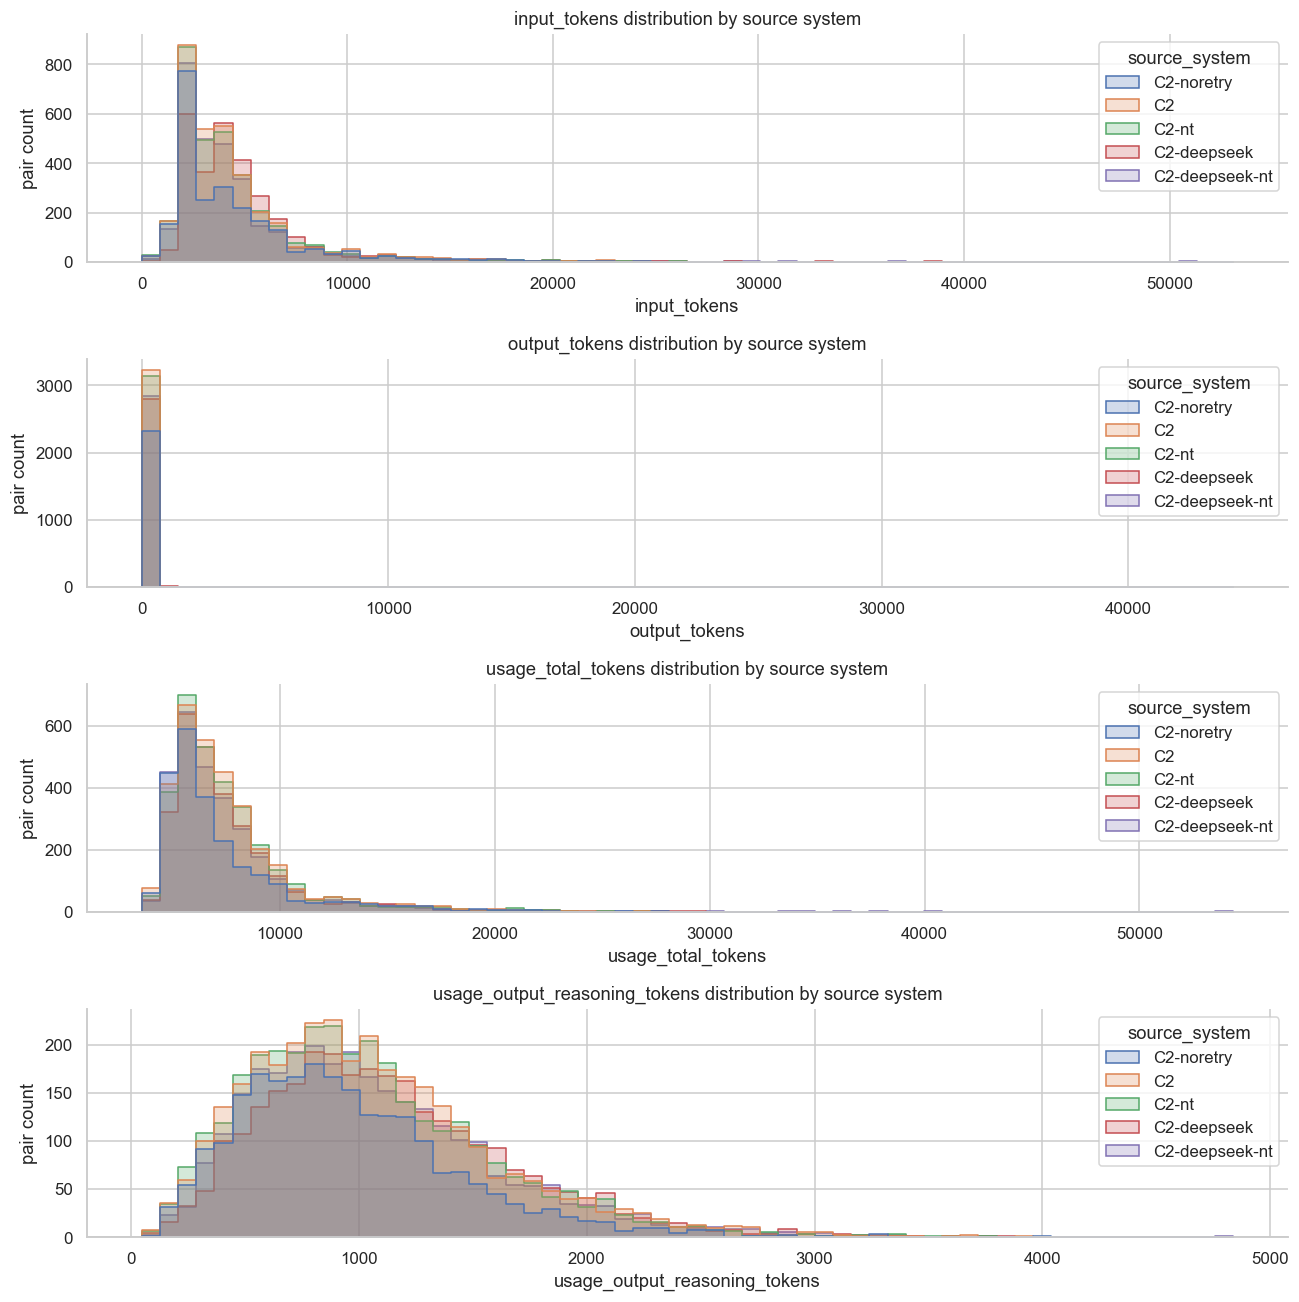

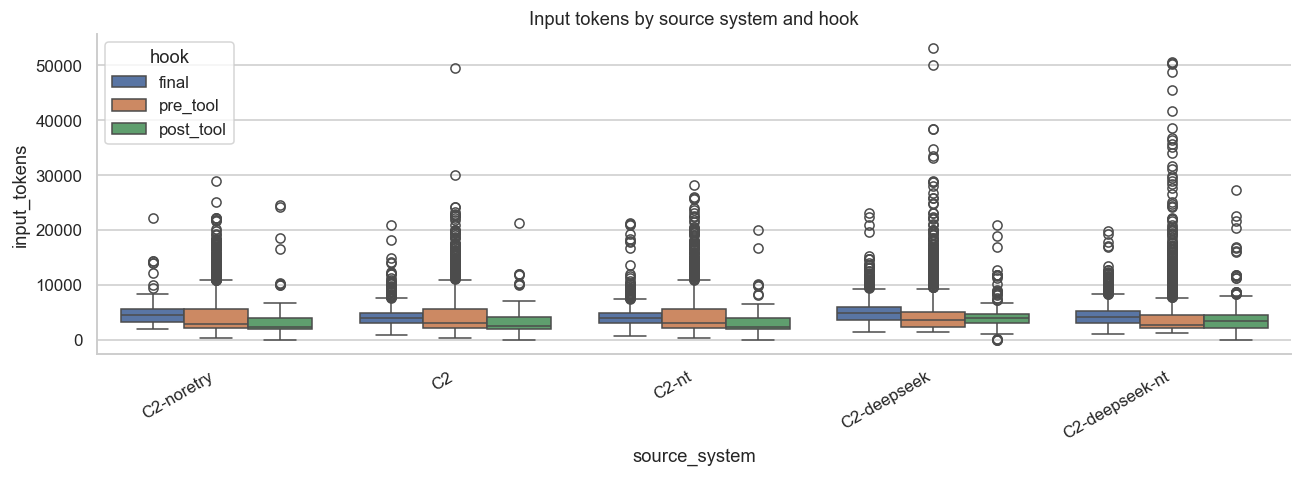

In [14]:
fig, axes = plt.subplots(len(TOKEN_FIELDS), 1, figsize=(12, 3.0 * len(TOKEN_FIELDS)))
for ax, field in zip(axes, TOKEN_FIELDS):
    sns.histplot(
        data=pairs,
        x=field,
        hue="source_system",
        bins=60,
        element="step",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"{field} distribution by source system")
    ax.set_xlabel(field)
    ax.set_ylabel("pair count")
plt.tight_layout()

plt.figure(figsize=(12, 4.5))
sns.boxplot(data=pairs, x="source_system", y="input_tokens", hue="hook")
plt.title("Input tokens by source system and hook")
plt.xlabel("source_system")
plt.ylabel("input_tokens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Reasoning Strip Audit

`reasoning_stripped` should show whether hidden reasoning was removed from the target. The expected mapping below follows repo configs: `C2-noretry` is thinking-on; it only disables retries.

In [15]:
reasoning_crosstab = pd.crosstab(
    [pairs["source_system"], pairs["overseer_mode"]],
    pairs["reasoning_stripped"].astype("string").fillna("<missing>"),
    dropna=False,
)
display(reasoning_crosstab)

reasoning_expected = (
    pairs.groupby(["source_system", "overseer_mode", "expected_reasoning_stripped", "reasoning_stripped"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["source_system", "overseer_mode", "expected_reasoning_stripped", "reasoning_stripped"])
)
display(reasoning_expected)

reasoning_violations = pairs[
    pairs["expected_reasoning_stripped"].notna()
    & pairs["reasoning_stripped"].notna()
    & (pairs["reasoning_stripped"] != pairs["expected_reasoning_stripped"])
]
reasoning_strip_ok = reasoning_violations.empty
print(f"reasoning_strip_ok={reasoning_strip_ok}; violation_rows={len(reasoning_violations):,}")

display(
    reasoning_violations.groupby(["source_system", "overseer_mode", "reasoning_stripped", "expected_reasoning_stripped"], dropna=False)
    .size()
    .reset_index(name="violation_rows")
)

reasoning_stripped            False
source_system  overseer_mode       
C2             non-thinking       0
               thinking        3242
C2-deepseek    non-thinking       0
               thinking        2803
C2-deepseek-nt non-thinking    2849
               thinking           0
C2-noretry     non-thinking       0
               thinking        2328
C2-nt          non-thinking    3149
               thinking           0

,source_system,overseer_mode,expected_reasoning_stripped,reasoning_stripped,count
0,C2,thinking,True,False,3242
1,C2-deepseek,thinking,True,False,2803
2,C2-deepseek-nt,non-thinking,False,False,2849
3,C2-noretry,thinking,True,False,2328
4,C2-nt,non-thinking,False,False,3149


reasoning_strip_ok=False; violation_rows=8,373


,source_system,overseer_mode,reasoning_stripped,expected_reasoning_stripped,violation_rows
0,C2,thinking,False,True,3242
1,C2-deepseek,thinking,False,True,2803
2,C2-noretry,thinking,False,True,2328


## Match Resolution Audit

`match_resolution` shows how Langfuse observations were joined back to local run logs. Timestamp-only or fallback matches are weaker than task-query or exact-text matches.

In [16]:
def count_with_pct(df: pd.DataFrame, group_cols: list[str], label_col: str) -> pd.DataFrame:
    group_keys = group_cols + [label_col]
    table = (
        df.groupby(group_keys, dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(group_cols + ["count"], ascending=[True] * len(group_cols) + [False])
    )
    if group_cols:
        table["pct_in_group"] = table["count"] / table.groupby(group_cols)["count"].transform("sum")
    else:
        table["pct_in_group"] = table["count"] / table["count"].sum()
    return table


match_resolution_counts = count_with_pct(pairs, [], "match_resolution")
match_resolution_by_system = count_with_pct(pairs, ["source_system"], "match_resolution")
match_resolution_by_split = count_with_pct(pairs, ["split"], "match_resolution")

display(match_resolution_counts)
display(match_resolution_by_system)
display(match_resolution_by_split)

weak_match_mask = pairs["match_resolution"].fillna("").str.contains("timestamp|fallback|order", case=False, regex=True)
weak_match_rows = pairs[weak_match_mask]
weak_match_fraction = len(weak_match_rows) / len(pairs) if len(pairs) else 0.0
print(f"weak_match_rows={len(weak_match_rows):,}; weak_match_fraction={weak_match_fraction:.3%}")
display(weak_match_rows[["source_system", "session_id", "run_id", "level", "task_key", "hook_trigger", "match_resolution"]].head(20))

,match_resolution,count,pct_in_group
0,task_query_match,14371,1.0


,source_system,match_resolution,count,pct_in_group
0,C2,task_query_match,3242,1.0
1,C2-deepseek,task_query_match,2803,1.0
2,C2-deepseek-nt,task_query_match,2849,1.0
3,C2-noretry,task_query_match,2328,1.0
4,C2-nt,task_query_match,3149,1.0


,split,match_resolution,count,pct_in_group
0,held_out,task_query_match,3397,1.0
1,train,task_query_match,9020,1.0
2,val,task_query_match,1954,1.0


weak_match_rows=0; weak_match_fraction=0.000%


,source_system,session_id,run_id,level,task_key,hook_trigger,match_resolution


## Class Balance

`decision_label` is the training class. The majority-class baseline is the key sanity check for a simple Check-B-style threshold.

Class balance by split


,split,decision_label,count,pct_in_group
0,held_out,approve,1761,0.518399
2,held_out,provide_guidance,907,0.267000
3,held_out,run_verification,722,0.212540
1,held_out,correct_observation,7,0.002061
4,train,approve,3935,0.436253
7,train,run_verification,2968,0.329047
6,train,provide_guidance,2115,0.234479
5,train,correct_observation,2,0.000222
8,val,approve,910,0.465711
11,val,run_verification,601,0.307574


Majority-class baseline by split


,majority_class_pct,below_threshold
split,,
held_out,0.518399,True
train,0.436253,True
val,0.465711,True


Class balance by hook


...

Class balance by source system


,source_system,decision_label,count,pct_in_group
0,C2,approve,1486,0.458359
3,C2,run_verification,1017,0.313695
2,C2,provide_guidance,738,0.227637
1,C2,correct_observation,1,0.000308
4,C2-deepseek,approve,1187,0.423475
7,C2-deepseek,run_verification,946,0.337496
6,C2-deepseek,provide_guidance,667,0.237959
5,C2-deepseek,correct_observation,3,0.001070
8,C2-deepseek-nt,approve,1240,0.435240
11,C2-deepseek-nt,run_verification,953,0.334503


Class balance by executor family


,executor_family,decision_label,count,pct_in_group
0,deepseek,approve,2427,0.429406
3,deepseek,run_verification,1899,0.335987
2,deepseek,provide_guidance,1320,0.233546
1,deepseek,correct_observation,6,0.001062
4,qwen,approve,4179,0.479298
7,qwen,run_verification,2392,0.274343
6,qwen,provide_guidance,2143,0.245785
5,qwen,correct_observation,5,0.000573


split,held_out,train,val
decision_label,,,
approve,1761,3935,910
correct_observation,7,2,2
provide_guidance,907,2115,441
run_verification,722,2968,601


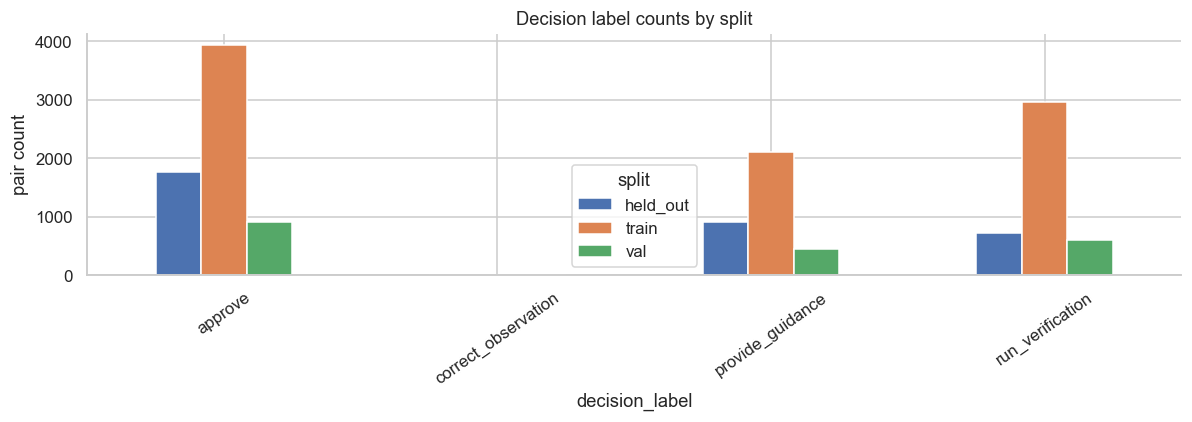

In [17]:
class_balance = count_with_pct(pairs, ["split"], "decision_label")
hook_class_balance = count_with_pct(pairs, ["hook"], "decision_label")
class_by_system = count_with_pct(pairs, ["source_system"], "decision_label")
class_by_split_system = count_with_pct(pairs, ["split", "source_system"], "decision_label")
class_by_executor_family = count_with_pct(pairs, ["executor_family"], "decision_label")

majority_by_split = (
    pairs.groupby("split", dropna=False)["decision_label"]
    .apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0] if len(s) else pd.NA)
    .rename("majority_class_pct")
    .to_frame()
)
majority_by_split["below_threshold"] = majority_by_split["majority_class_pct"] <= MAJORITY_CLASS_THRESHOLD
majority_below_threshold = bool(majority_by_split["below_threshold"].all())

print("Class balance by split")
display(class_balance)

print("Majority-class baseline by split")
display(majority_by_split)

print("Class balance by hook")
display(hook_class_balance)

print("Class balance by source system")
display(class_by_system)

print("Class balance by executor family")
display(class_by_executor_family)

class_pivot = pairs.pivot_table(
    index="decision_label",
    columns="split",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
).sort_index()
display(class_pivot)

ax = class_pivot.plot(kind="bar", figsize=(11, 4), rot=35)
ax.set_title("Decision label counts by split")
ax.set_xlabel("decision_label")
ax.set_ylabel("pair count")
plt.tight_layout()

hook_trigger,final / final_checkpoint,post_tool / error_occurrence,pre_tool / loop_detection,pre_tool / mutating_action
decision_label,,,,
approve,848,2,707,5049
run_verification,4291,0,0,0
provide_guidance,0,1153,233,2077
correct_observation,0,10,0,1


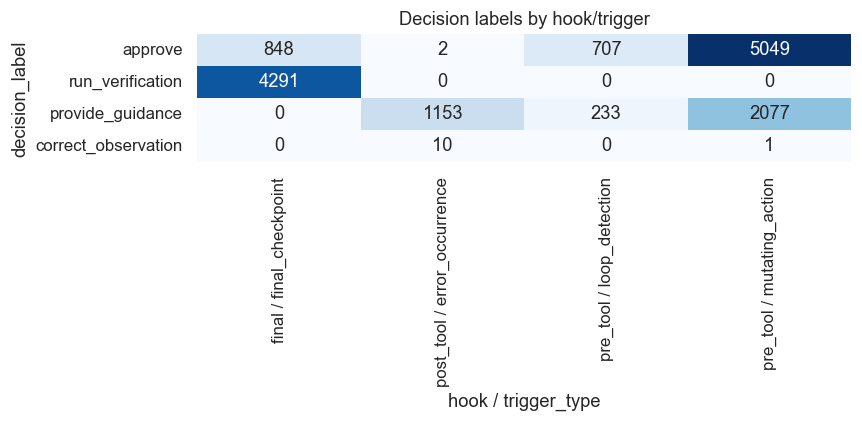

In [18]:
label_hook_matrix = pairs.pivot_table(
    index="decision_label",
    columns="hook_trigger",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
label_hook_matrix = label_hook_matrix.loc[label_hook_matrix.sum(axis=1).sort_values(ascending=False).index]

display(label_hook_matrix)

plt.figure(figsize=(max(8, 0.55 * len(label_hook_matrix.columns)), max(4, 0.35 * len(label_hook_matrix))))
sns.heatmap(label_hook_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Decision labels by hook/trigger")
plt.xlabel("hook / trigger_type")
plt.ylabel("decision_label")
plt.tight_layout()

## Cross-Execution Balance

Execution means one `(source_system, session_id, run_id)` source. These tables show whether one system, run, level, or task dominates the corpus.

,source_system,session_id,run_id,pairs,unique_tasks,unique_levels,final_pairs,runtime_pairs,parse_clean_rate,missing_levels,levels_missing_count,final_pct
0,C2,2026-04-30_09-18-02,0,757,117,3,307,450,1.0,[],0,0.405548
1,C2,2026-04-30_09-18-02,1,828,120,3,297,531,1.0,[],0,0.358696
2,C2,2026-04-30_09-18-02,2,869,120,3,290,579,1.0,[],0,0.333717
3,C2,2026-04-30_09-18-02,3,788,120,3,305,483,1.0,[],0,0.387056
4,C2-deepseek,2026-05-01_18-54-47,0,683,117,3,298,385,1.0,[],0,0.436310
5,C2-deepseek,2026-05-01_18-54-47,1,726,120,3,286,440,1.0,[],0,0.393939
6,C2-deepseek,2026-05-10_18-11-57,0,690,119,3,281,409,1.0,[],0,0.407246
7,C2-deepseek,2026-05-10_18-11-57,1,704,119,3,295,409,1.0,[],0,0.419034
8,C2-deepseek-nt,2026-05-10_18-08-50,0,744,120,3,299,445,1.0,[],0,0.401882
9,C2-deepseek-nt,2026-05-10_18-08-50,1,710,120,3,292,418,1.0,[],0,0.411268


split,held_out,train,val,total
source_system,,,,
C2,700,2076,466,3242
C2-nt,691,2048,410,3149
C2-deepseek-nt,734,1727,388,2849
C2-deepseek,676,1731,396,2803
C2-noretry,596,1438,294,2328


level,1,2,3
source_system,,,
C2,1293,1177,772
C2-deepseek,960,1033,810
C2-deepseek-nt,1001,993,855
C2-noretry,855,701,772
C2-nt,1280,1129,740


split,held_out,train,val,total
executor_family,,,,
qwen,1987,5562,1170,8719
deepseek,1410,3458,784,5652


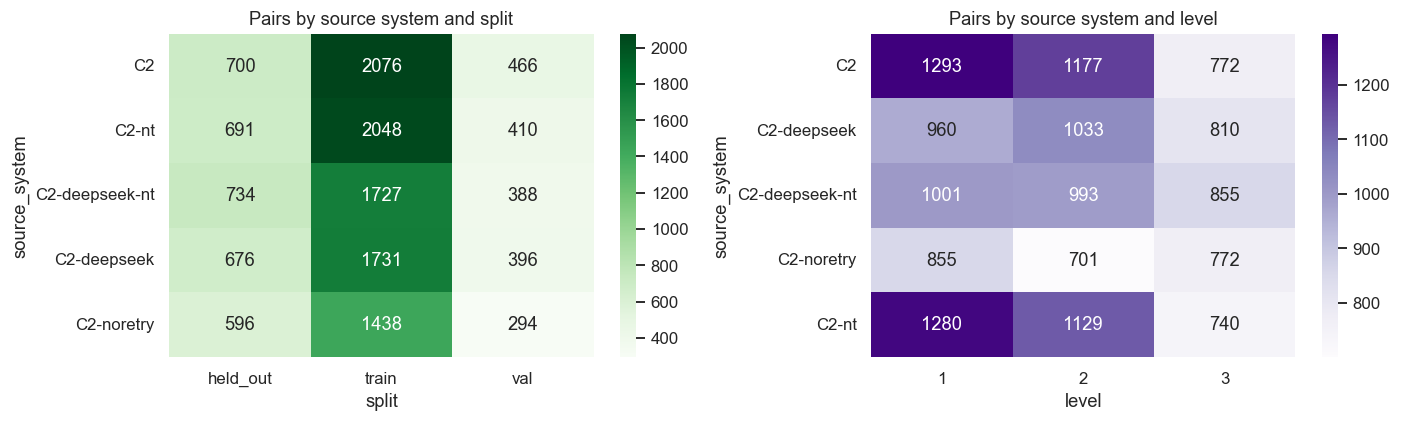

In [19]:
execution_group = ["source_system", "session_id", "run_id"]
levels_by_execution = (
    pairs.groupby(execution_group, dropna=False)["level"]
    .apply(lambda s: sorted(EXPECTED_LEVELS - set(s.dropna().astype(int))))
    .reset_index(name="missing_levels")
)
levels_by_execution["levels_missing_count"] = levels_by_execution["missing_levels"].apply(len)

execution_counts = (
    pairs.groupby(execution_group, dropna=False)
    .agg(
        pairs=("pair_id", "count"),
        unique_tasks=("task_key", "nunique"),
        unique_levels=("level", "nunique"),
        final_pairs=("hook", lambda s: int((s == "final").sum())),
        runtime_pairs=("hook", lambda s: int((s != "final").sum())),
        parse_clean_rate=("parse_clean", "mean"),
    )
    .reset_index()
    .merge(levels_by_execution, on=execution_group, how="left")
    .sort_values(execution_group)
)
execution_counts["final_pct"] = execution_counts["final_pairs"] / execution_counts["pairs"]
no_missing_levels = bool((execution_counts["levels_missing_count"] == 0).all())
display(execution_counts)

system_split = pairs.pivot_table(
    index="source_system",
    columns="split",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
system_split["total"] = system_split.sum(axis=1)
system_split = system_split.sort_values("total", ascending=False)
display(system_split)

system_level = pairs.pivot_table(
    index="source_system",
    columns="level",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
).sort_index()
display(system_level)

executor_split = pairs.pivot_table(
    index="executor_family",
    columns="split",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
executor_split["total"] = executor_split.sum(axis=1)
display(executor_split.sort_values("total", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(system_split.drop(columns=["total"], errors="ignore"), annot=True, fmt="d", cmap="Greens", ax=axes[0])
axes[0].set_title("Pairs by source system and split")
axes[0].set_xlabel("split")
axes[0].set_ylabel("source_system")

sns.heatmap(system_level, annot=True, fmt="d", cmap="Purples", ax=axes[1])
axes[1].set_title("Pairs by source system and level")
axes[1].set_xlabel("level")
axes[1].set_ylabel("source_system")
plt.tight_layout()

,source_system,split,level,count,mean,std,min,q25,median,q75,max,max_to_min
0,C2,held_out,1,8.0,24.375000,5.153016,18.0,19.50,25.5,28.25,31.0,1.722222
1,C2,held_out,2,8.0,21.000000,6.803361,15.0,16.00,19.5,23.00,36.0,2.400000
2,C2,held_out,3,8.0,42.125000,14.584116,21.0,34.00,41.0,55.00,60.0,2.857143
3,C2,train,1,35.0,25.400000,6.074053,14.0,22.00,26.0,28.00,39.0,2.785714
4,C2,train,2,35.0,23.714286,9.451335,15.0,17.00,21.0,26.50,56.0,3.733333
5,C2,train,3,10.0,35.700000,12.499333,18.0,25.50,40.0,42.75,56.0,3.111111
6,C2,val,1,7.0,29.857143,6.067085,22.0,26.00,30.0,32.50,40.0,1.818182
7,C2,val,2,7.0,25.571429,10.674848,14.0,16.50,24.0,34.00,40.0,2.857143
8,C2,val,3,2.0,39.000000,16.970563,27.0,33.00,39.0,45.00,51.0,1.888889
9,C2-deepseek,held_out,1,8.0,18.250000,4.097037,13.0,15.75,17.5,20.00,25.0,1.923077


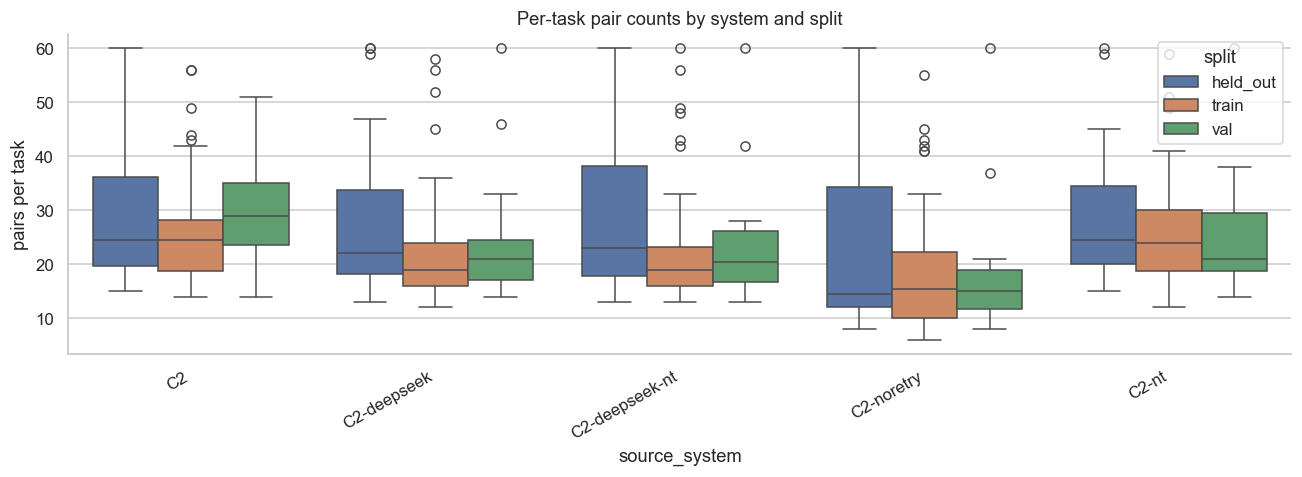

In [20]:
per_task_counts = (
    pairs.groupby(["source_system", "split", "level", "task_key"], dropna=False)
    .agg(
        pairs=("pair_id", "count"),
        executions=("execution_key", "nunique"),
        hooks=("hook_trigger", "nunique"),
        labels=("decision_label", "nunique"),
    )
    .reset_index()
)

per_task_balance = (
    per_task_counts.groupby(["source_system", "split", "level"], dropna=False)["pairs"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .reset_index()
)
per_task_balance = per_task_balance.rename(columns={"25%": "q25", "50%": "median", "75%": "q75"})
per_task_balance["max_to_min"] = per_task_balance["max"] / per_task_balance["min"].replace({0: pd.NA})
display(per_task_balance)

plt.figure(figsize=(12, 4.5))
sns.boxplot(data=per_task_counts, x="source_system", y="pairs", hue="split")
plt.title("Per-task pair counts by system and split")
plt.xlabel("source_system")
plt.ylabel("pairs per task")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Hook Type Coverage

These tables expose missing or lopsided hook coverage. Read `hook / trigger_type` as the prompt family being trained.

Hook/trigger balance by split


,split,hook_trigger,count,pct_in_group
3,held_out,pre_tool / mutating_action,1928,0.567560
0,held_out,final / final_checkpoint,876,0.257875
1,held_out,post_tool / error_occurrence,401,0.118045
2,held_out,pre_tool / loop_detection,192,0.056520
7,train,pre_tool / mutating_action,4228,0.468736
4,train,final / final_checkpoint,3560,0.394678
5,train,post_tool / error_occurrence,639,0.070843
6,train,pre_tool / loop_detection,593,0.065743
11,val,pre_tool / mutating_action,971,0.496929
8,val,final / final_checkpoint,703,0.359775


source_system,C2,C2-deepseek,C2-deepseek-nt,C2-noretry,C2-nt
hook_trigger,,,,,
pre_tool / mutating_action,1573,1280,1292,1456,1526
final / final_checkpoint,1199,1160,1167,450,1163
post_tool / error_occurrence,209,256,293,205,202
pre_tool / loop_detection,261,107,97,217,258


source_system,C2,C2-deepseek,C2-deepseek-nt,C2-noretry,C2-nt
hook_trigger,,,,,
pre_tool / mutating_action,0.220710,0.179599,0.181282,0.204294,0.214115
final / final_checkpoint,0.233314,0.225725,0.227087,0.087566,0.226309
post_tool / error_occurrence,0.179399,0.219742,0.251502,0.175966,0.173391
pre_tool / loop_detection,0.277660,0.113830,0.103191,0.230851,0.274468


split,held_out,train,val
hook_trigger,,,
pre_tool / mutating_action,1928,4228,971
final / final_checkpoint,876,3560,703
post_tool / error_occurrence,401,639,125
pre_tool / loop_detection,192,593,155


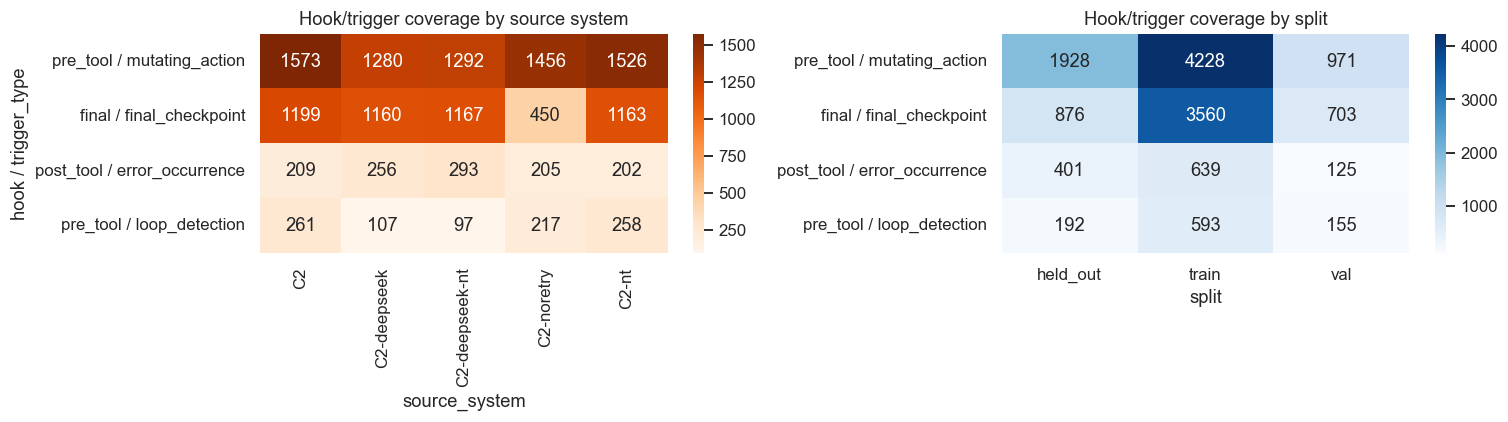

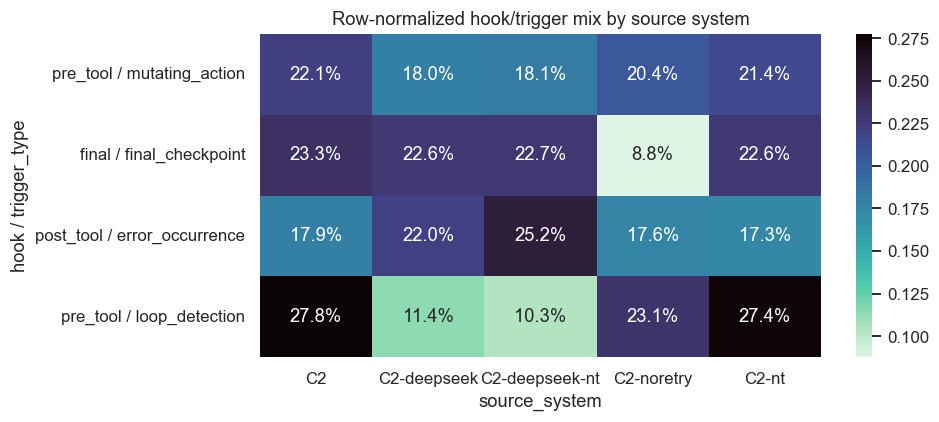

In [21]:
hook_counts = count_with_pct(pairs, ["split"], "hook_trigger")
print("Hook/trigger balance by split")
display(hook_counts)

hook_by_system = pairs.pivot_table(
    index="hook_trigger",
    columns="source_system",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
hook_by_system = hook_by_system.loc[hook_by_system.sum(axis=1).sort_values(ascending=False).index]
display(hook_by_system)

hook_by_system_pct = hook_by_system.div(hook_by_system.sum(axis=1).replace(0, pd.NA), axis=0)
display(hook_by_system_pct)

hook_by_split = pairs.pivot_table(
    index="hook_trigger",
    columns="split",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
hook_by_split = hook_by_split.loc[hook_by_split.sum(axis=1).sort_values(ascending=False).index]
display(hook_by_split)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35 * len(hook_by_system))))
sns.heatmap(hook_by_system, annot=True, fmt="d", cmap="Oranges", ax=axes[0])
axes[0].set_title("Hook/trigger coverage by source system")
axes[0].set_xlabel("source_system")
axes[0].set_ylabel("hook / trigger_type")

sns.heatmap(hook_by_split, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Hook/trigger coverage by split")
axes[1].set_xlabel("split")
axes[1].set_ylabel("")
plt.tight_layout()

plt.figure(figsize=(9, max(4, 0.35 * len(hook_by_system_pct))))
sns.heatmap(hook_by_system_pct, annot=True, fmt=".1%", cmap="mako_r")
plt.title("Row-normalized hook/trigger mix by source system")
plt.xlabel("source_system")
plt.ylabel("hook / trigger_type")
plt.tight_layout()

,hook_trigger,systems_present,systems_missing,total_pairs
0,pre_tool / mutating_action,5,,7127
1,final / final_checkpoint,5,,5139
2,post_tool / error_occurrence,5,,1165
3,pre_tool / loop_detection,5,,940


level,1,2,3
hook_trigger,,,
pre_tool / mutating_action,2270,2097,2760
final / final_checkpoint,2384,2292,463
post_tool / error_occurrence,188,354,623
pre_tool / loop_detection,547,290,103


hook_trigger,final / final_checkpoint,post_tool / error_occurrence,pre_tool / loop_detection,pre_tool / mutating_action
phase,,,,
cart_check,5139,291,666,2361
initial,0,874,274,4766


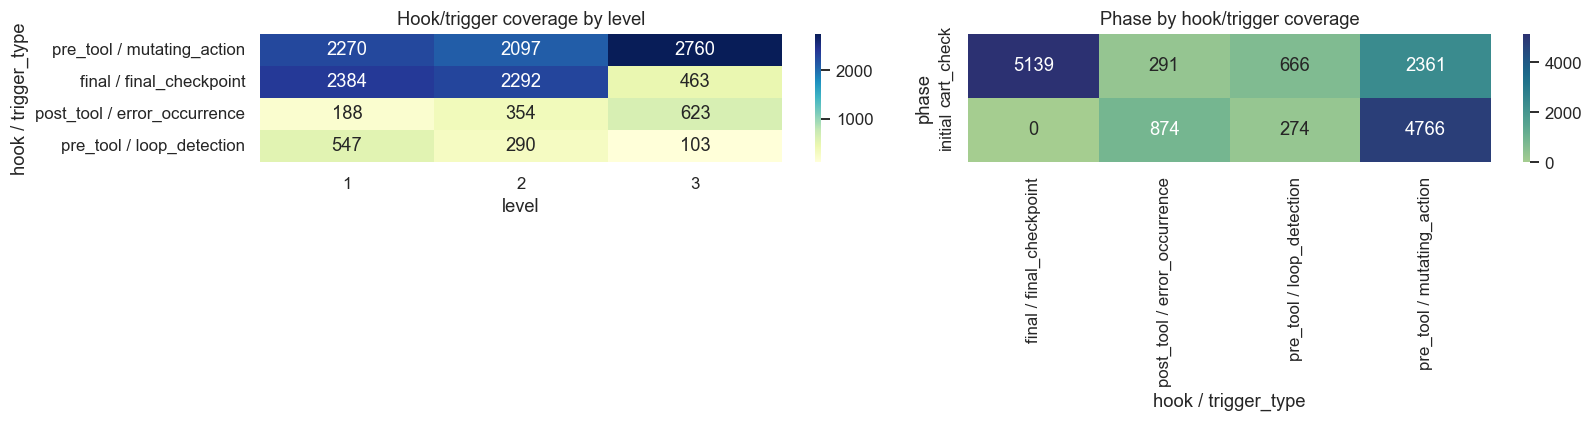

In [22]:
coverage_rows = []
for hook_trigger, row in hook_by_system.iterrows():
    missing_systems = row[row == 0].index.tolist()
    coverage_rows.append(
        {
            "hook_trigger": hook_trigger,
            "systems_present": int((row > 0).sum()),
            "systems_missing": ", ".join(missing_systems),
            "total_pairs": int(row.sum()),
        }
    )
coverage_summary = pd.DataFrame(coverage_rows).sort_values(["systems_present", "total_pairs"], ascending=[True, False])
display(coverage_summary)

hook_level = pairs.pivot_table(
    index="hook_trigger",
    columns="level",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
hook_level = hook_level.loc[hook_level.sum(axis=1).sort_values(ascending=False).index]
display(hook_level)

phase_hook = pairs.pivot_table(
    index="phase",
    columns="hook_trigger",
    values="pair_id",
    aggfunc="count",
    fill_value=0,
)
phase_hook = phase_hook.loc[phase_hook.sum(axis=1).sort_values(ascending=False).index]
display(phase_hook)

fig, axes = plt.subplots(1, 2, figsize=(15, max(4, 0.35 * max(len(hook_level), len(phase_hook)))))
sns.heatmap(hook_level, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Hook/trigger coverage by level")
axes[0].set_xlabel("level")
axes[0].set_ylabel("hook / trigger_type")

sns.heatmap(phase_hook, annot=True, fmt="d", cmap="crest", ax=axes[1])
axes[1].set_title("Phase by hook/trigger coverage")
axes[1].set_xlabel("hook / trigger_type")
axes[1].set_ylabel("phase")
plt.tight_layout()

## Split-Freeze Gate

This final cell collapses the hard checks into one boolean. It does not raise by default, so the notebook can still render diagnostics when a check fails.

In [23]:
gate_checks = pd.Series(
    {
        "no_manifest_drift": no_manifest_drift,
        "no_duplicate_pair_id_rows": sanity["duplicate_pair_id_rows"] == 0,
        "no_duplicate_source_observation_rows": sanity["duplicate_source_observation_rows"] == 0,
        "no_split_task_leakage": no_split_task_leakage,
        "no_file_split_mismatch_rows": sanity["file_split_mismatch_rows"] == 0,
        "no_unknown_split_rows": sanity["unknown_split_rows"] == 0,
        "all_rows_parse_clean": sanity["parse_clean_rows"] == sanity["rows_loaded_from_training_splits"],
        "all_inputs_from_langfuse": sanity["missing_input_source_rows"] == 0,
        "reasoning_strip_ok": reasoning_strip_ok,
        "majority_class_below_threshold": majority_below_threshold,
        "no_missing_execution_levels": no_missing_levels,
    },
    name="pass",
)
READY_FOR_SPLIT_FREEZE = bool(gate_checks.all())

display(gate_checks.to_frame())
print(f"READY_FOR_SPLIT_FREEZE={READY_FOR_SPLIT_FREEZE}")

if not READY_FOR_SPLIT_FREEZE:
    print("Failed checks:")
    display(gate_checks[~gate_checks].to_frame())

,pass
no_manifest_drift,True
no_duplicate_pair_id_rows,True
no_duplicate_source_observation_rows,True
no_split_task_leakage,True
no_file_split_mismatch_rows,True
no_unknown_split_rows,True
all_rows_parse_clean,True
all_inputs_from_langfuse,True
reasoning_strip_ok,False
majority_class_below_threshold,True


READY_FOR_SPLIT_FREEZE=False
Failed checks:


,pass
reasoning_strip_ok,False


## Optional Table Export

Set `WRITE_TABLES = True` to write the main tables as CSV under `outputs/deepplanning/lora_sft/exploration_tables/`.

In [24]:
WRITE_TABLES = False
TABLE_DIR = DATASET_DIR / "exploration_tables"

if WRITE_TABLES:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    class_balance.to_csv(TABLE_DIR / "class_balance_by_split.csv", index=False)
    hook_class_balance.to_csv(TABLE_DIR / "class_balance_by_hook.csv", index=False)
    class_by_split_system.to_csv(TABLE_DIR / "class_balance_by_split_system.csv", index=False)
    class_by_executor_family.to_csv(TABLE_DIR / "class_balance_by_executor_family.csv", index=False)
    majority_by_split.to_csv(TABLE_DIR / "majority_class_baseline_by_split.csv")
    match_resolution_counts.to_csv(TABLE_DIR / "match_resolution_counts.csv", index=False)
    match_resolution_by_system.to_csv(TABLE_DIR / "match_resolution_by_system.csv", index=False)
    token_quantiles.to_csv(TABLE_DIR / "token_quantiles.csv")
    token_by_system.to_csv(TABLE_DIR / "token_quantiles_by_system.csv")
    execution_counts.to_csv(TABLE_DIR / "execution_counts.csv", index=False)
    per_task_balance.to_csv(TABLE_DIR / "per_task_balance.csv", index=False)
    hook_counts.to_csv(TABLE_DIR / "hook_balance_by_split.csv", index=False)
    hook_by_system.to_csv(TABLE_DIR / "hook_by_system.csv")
    hook_by_system_pct.to_csv(TABLE_DIR / "hook_by_system_row_normalized.csv")
    hook_by_split.to_csv(TABLE_DIR / "hook_by_split.csv")
    phase_hook.to_csv(TABLE_DIR / "phase_by_hook.csv")
    coverage_summary.to_csv(TABLE_DIR / "hook_coverage_summary.csv", index=False)
    gate_checks.to_csv(TABLE_DIR / "split_freeze_gate_checks.csv")
    print(f"Wrote CSV tables to {TABLE_DIR}")
else:
    print("Table export disabled")

Table export disabled
